# Indoor Object Detection — YOLO11s

Trains and evaluates a 7-class indoor object detector (`chair`, `clock`, `exit`, `fireextinguisher`, `printer`, `screen`, `trashbin`) on the TUT Indoor Object Detection Dataset.

**What this notebook produces**

1. Exploratory analysis of the 2,213 annotated frames.
2. A leak-free 80/10/10 split with all seven classes in every split.
3. A trained YOLO11s model.
4. Per-class **and** whole-set validation mAP, computed with `pycocotools`.
5. Good and bad qualitative examples from the validation set.
6. A measured comparison against the naive random split, to show how much mAP that split inflates.

**Runtime:** `Runtime → Change runtime type → GPU`. An **L4** (Colab Pro) completes the full run comfortably; a free **T4** also works but takes roughly twice as long.

## 1 · Environment

In [1]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

import torch, platform
print('python', platform.python_version())
print('torch ', torch.__version__, '| cuda', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device', torch.cuda.get_device_name(0))

name, memory.total [MiB], driver_version
NVIDIA L4, 23034 MiB, 580.82.07
python 3.13.15
torch  2.11.0+cu128 | cuda True
device NVIDIA L4


### Get the code

Clones the public repository. Change `REPO_URL` only if you are running from a fork.

In [2]:
import os
from pathlib import Path

REPO_URL = "https://github.com/zaiter93/indoor-object-detection"
REPO_DIR = Path("/content/indoor-object-detection")

if not REPO_DIR.exists():
    !git clone --depth 1 $REPO_URL {REPO_DIR}
os.chdir(REPO_DIR)
print('working directory:', Path.cwd())

Cloning into '/content/indoor-object-detection'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 40 (delta 0), reused 33 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 286.57 KiB | 1.19 MiB/s, done.
working directory: /content/indoor-object-detection


In [3]:
# Colab already ships a CUDA build of torch; installing it again wastes several minutes
# and risks a version conflict, so only the remaining packages are installed.
!pip install -q ultralytics pycocotools

import ultralytics, pycocotools
print('ultralytics', ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ultralytics 8.4.135


### Get the dataset

The dataset is ~400 MB, too large for a normal git repository, so it is attached to a GitHub Release. `DATASET_URL` below already points at it — no setup needed, the next cell just downloads and unzips it.

Clearing `DATASET_URL` falls back to mounting Google Drive, if you would rather supply your own copy.

In [4]:
DATASET_URL = "https://github.com/zaiter93/indoor-object-detection/releases/download/v1.0-dataset/indoor-object-detection-dataset.zip"
RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

if not (RAW_DIR / "Indoor Object Detection Dataset" / "annotation").exists():
    if DATASET_URL:
        !wget -q --show-progress -O /content/dataset.zip $DATASET_URL
    else:
        from google.colab import drive
        drive.mount('/content/drive')
        # Adjust this path to wherever you put the zip in your Drive.
        !cp '/content/drive/MyDrive/Indoor Object Detection Dataset.zip' /content/dataset.zip
    !unzip -q /content/dataset.zip -d {RAW_DIR}

!ls '{RAW_DIR}/Indoor Object Detection Dataset'

/content/dataset.zi 100%[===================>] 391.97M  35.5MB/s    in 11s     
annotation  sequence_1	sequence_3  sequence_5
info.txt    sequence_2	sequence_4  sequence_6


## 2 · Data analysis and splitting

`prepare_data.py` parses the dlib XML annotations, cleans them, runs the exploratory analysis, and materialises both splits in YOLO + COCO format.

It fails loudly if any split is missing a class, so the brief's "all classes in each split" requirement is enforced, not assumed.

In [5]:
!python prepare_data.py

[prepare] dataset root: /content/indoor-object-detection/data/raw/Indoor Object Detection Dataset
[prepare] 2213 images, 4594 boxes kept (11 clipped to bounds, 1 dropped as degenerate), 6 images with no objects, 0 annotated files missing on disk
[prepare] running exploratory analysis ...
[prepare]   4594 boxes, imbalance 20.8:1, median box 151.0 px
[prepare] grouped split chosen: {"block_size": 40, "seed": 1, "worst_class_support": 12, "max_ratio_deviation": 0.0096, "median_frame_gap": {"val": 12.0, "test": 13.0}, "candidates_considered": 80, "candidates_feasible": 29}

[prepare] --- grouped split ---
split   images    frac   boxes       chair     clock      exit fireextin   printer    screen  trashbin
------------------------------------------------------------------------------------------------------
train     1784   0.806    3682        1382       235       452      1302        43        68       200
val        200   0.090     522         188        20        57       207        19

### Why not a random split?

These are frames from six continuous video walk-throughs, not independent photographs. The figure below measures how quickly a frame stops resembling its neighbours: consecutive frames share a median box IoU of **0.68** (the same object, barely moved), falling to ~**0.03** by a gap of 10 frames.

A random split leaves a median gap of **1 frame** between each validation image and its nearest training image — it is scored on pictures it has effectively already seen. The grouped split raises that to **12 frames**.

**temporal_redundancy**

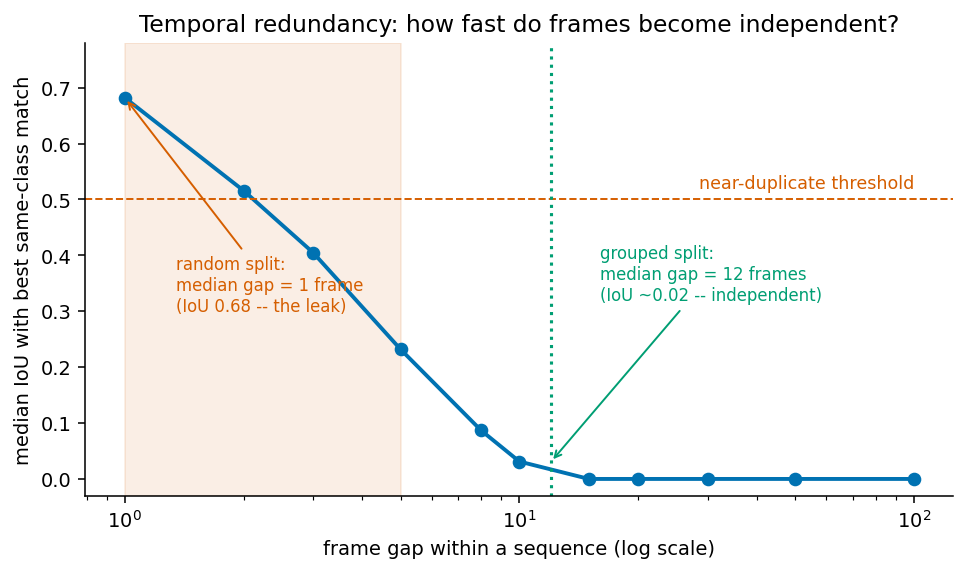

**class_distribution**

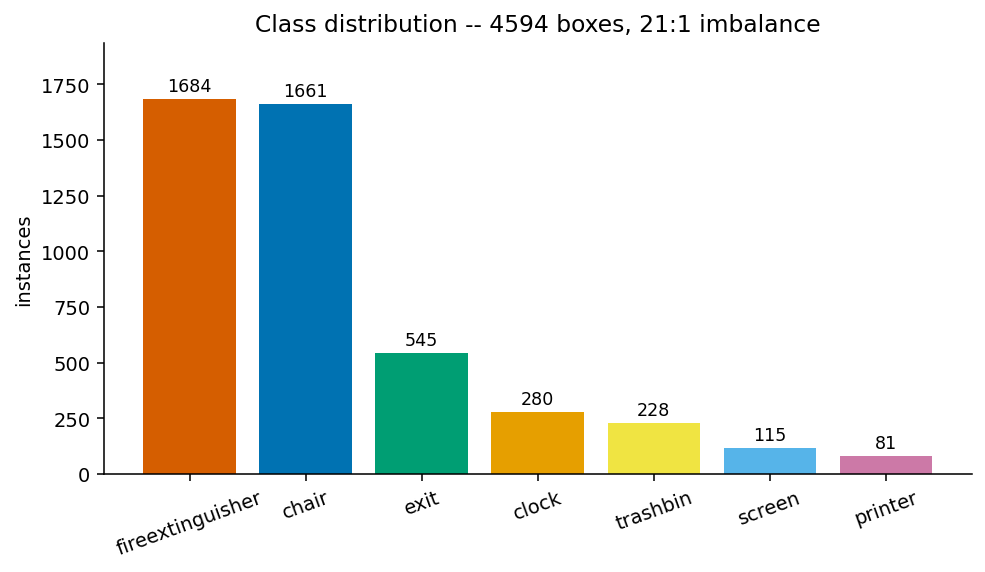

**per_sequence_heatmap**

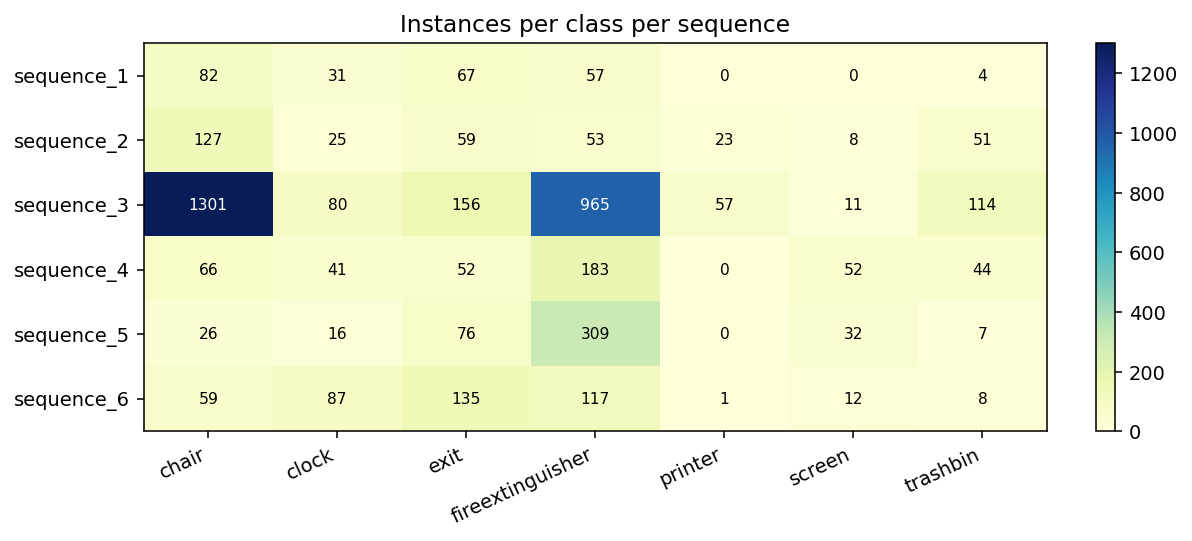

**box_sizes**

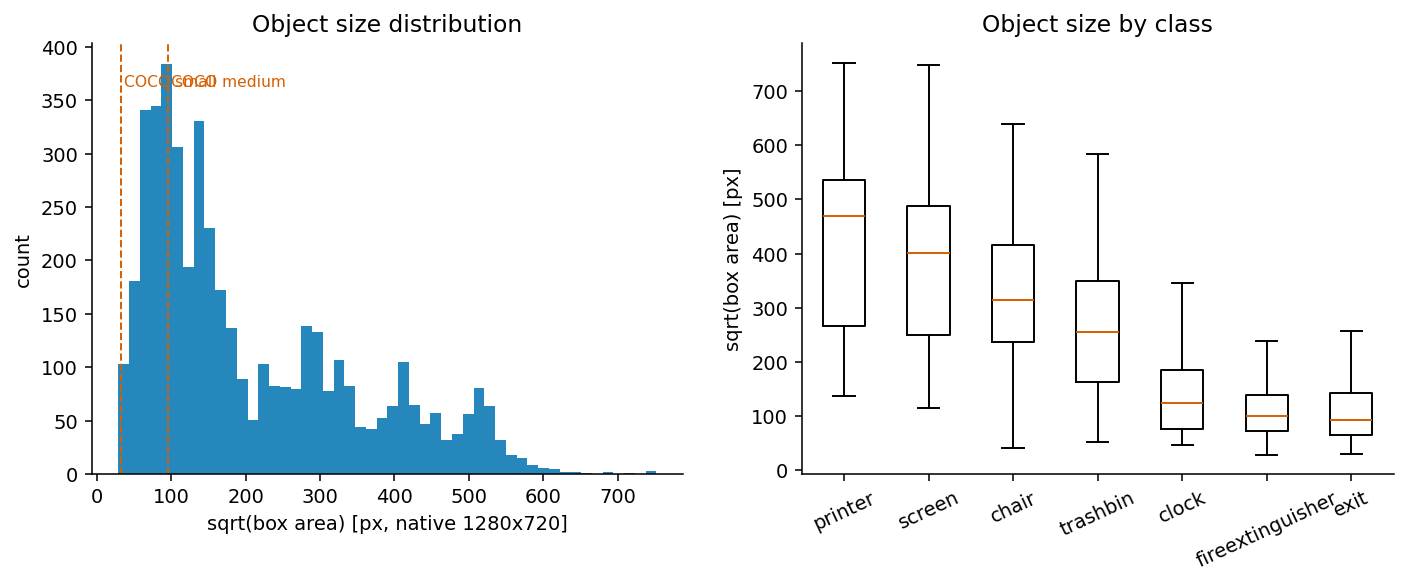

**spatial_heatmap**

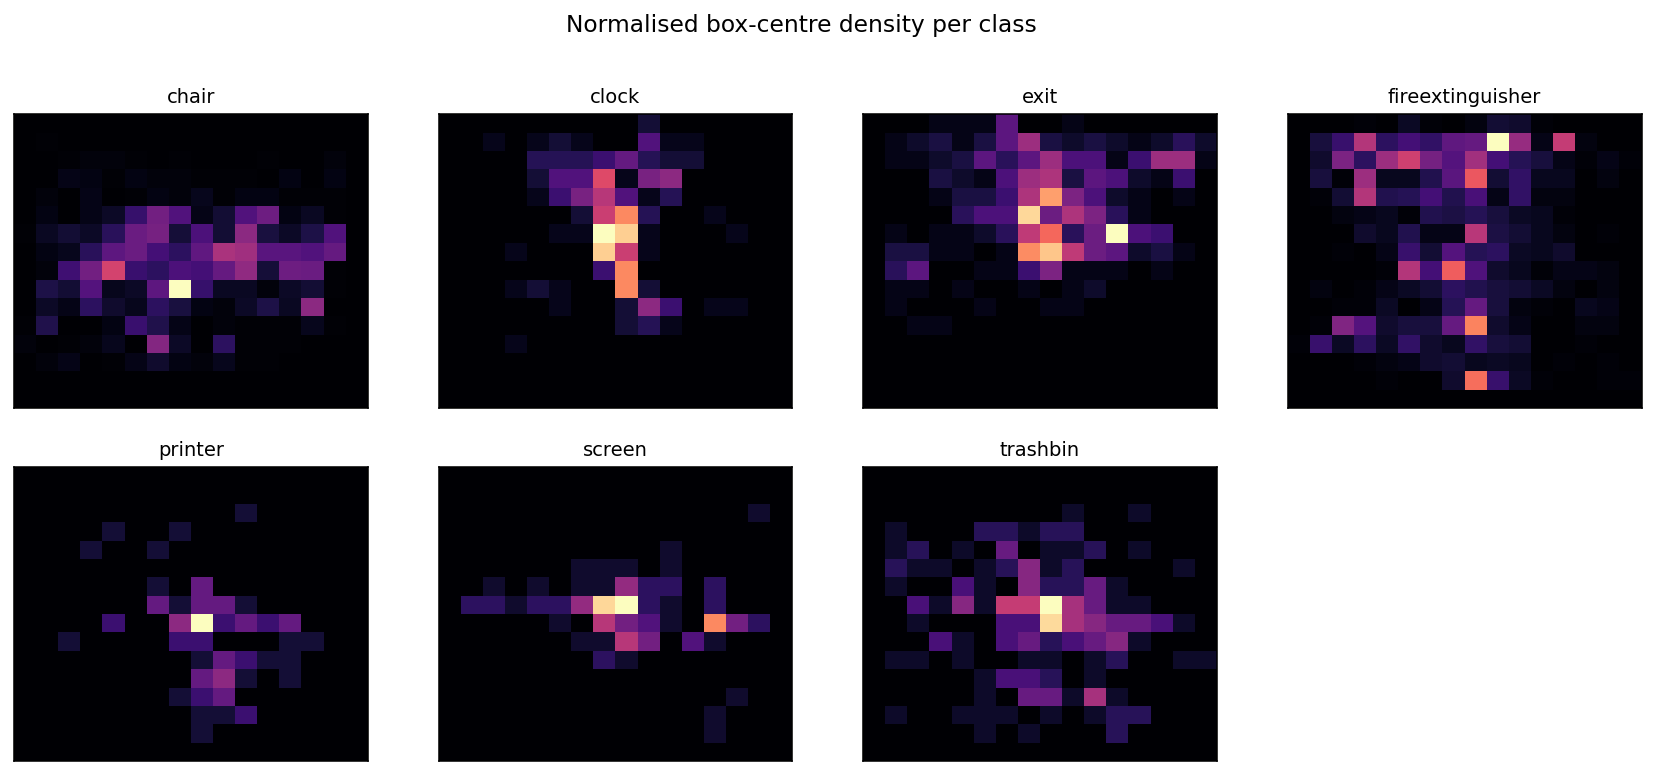

In [6]:
from IPython.display import Image, display, Markdown

for name in ['temporal_redundancy', 'class_distribution', 'per_sequence_heatmap',
             'box_sizes', 'spatial_heatmap']:
    display(Markdown(f'**{name}**'))
    display(Image(f'reports/figures/{name}.png'))

## 3 · Training

All hyperparameters live in `configs/default.yaml`, each with the reasoning that produced it. The headline choices:

| setting | value | why |
|---|---|---|
| model | `yolo11s` | 1.8k training frames from six rooms cannot support a larger backbone without overfitting; `n` leaves accuracy unused. |
| imgsz | 960 | Frames are 1280×720. At 640 the smallest 5% of boxes shrink to ~27 px; 960 keeps them near 41 px. |
| optimizer | AdamW, lr 1e-3, cosine | Converges in far fewer epochs than SGD on ~110 iterations/epoch with a pretrained backbone. |
| mosaic | 1.0, off for last 20 epochs | Multiplies effective exposure to rare classes; disabled at the end so training finishes on the real distribution. |
| flipud | 0.0 | These scenes are gravity-aligned — an upside-down exit sign cannot occur at inference time. |

In [7]:
!python train.py --config configs/default.yaml --dataset grouped --device 0

[train] model=yolo11s.pt  data=/content/indoor-object-detection/data/processed/grouped/dataset.yaml
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/indoor-object-detection/data/processed/grouped/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_rati

## 4 · Results

Per-class and whole-set mAP, computed by `pycocotools` at confidence 0.001 so the precision–recall curve is not truncated.

In [8]:
from IPython.display import Markdown, display
display(Markdown(open('reports/results.md').read()))

# Results

Model: `yolo11s.pt`  |  split: `grouped`  |  train imgsz: 960  |  epochs: 120

Metrics are computed with `pycocotools` against COCO-format ground truth,
at confidence threshold 0.001 so the precision-recall curve is complete.

## val (200 images, 522 objects)

| class | instances | AP@50 | AP@50-95 |
|---|---:|---:|---:|
| chair | 188 | 0.9948 | 0.8865 |
| clock | 20 | 0.9885 | 0.7558 |
| exit | 57 | 0.9918 | 0.7154 |
| fireextinguisher | 207 | 0.9983 | 0.7452 |
| printer | 19 | 0.8295 | 0.5224 |
| screen | 15 | 0.6811 | 0.3774 |
| trashbin | 16 | 0.9389 | 0.6771 |
| **all (macro)** | **522** | **0.9175** | **0.6685** |

Whole-set mAP@50-95 **0.6685**, mAP@50 **0.9175**, mAP@75 0.7717. By object size -- medium 0.6231, large 0.7117.

## test (229 images, 390 objects)

| class | instances | AP@50 | AP@50-95 |
|---|---:|---:|---:|
| chair | 91 | 0.9154 | 0.6613 |
| clock | 25 | 0.9985 | 0.7652 |
| exit | 36 | 1.0000 | 0.8093 |
| fireextinguisher | 175 | 0.9890 | 0.7871 |
| printer | 19 | 0.7450 | 0.5466 |
| screen | 32 | 0.7456 | 0.4344 |
| trashbin | 12 | 0.8924 | 0.5892 |
| **all (macro)** | **390** | **0.8980** | **0.6561** |

Whole-set mAP@50-95 **0.6561**, mAP@50 **0.8980**, mAP@75 0.8111. By object size -- medium 0.6230, large 0.6678.

## Qualitative analysis

Scored at confidence >= 0.25; mean per-image F1 0.9117.

| error type | count |
|---|---:|
| missed object (FN) | 18 |
| false positive (FP) | 42 |
|   of which wrong class | 1 |
|   of which loose box | 1 |
| true positive (TP) | 504 |

![good examples](figures/qualitative_good.png)

![bad examples](figures/qualitative_bad.png)


## 5 · Qualitative examples

Chosen automatically by per-image F1 — best six and worst six — so the selection cannot be cherry-picked. Dashed white boxes are ground truth; solid coloured boxes are predictions.

### Good examples

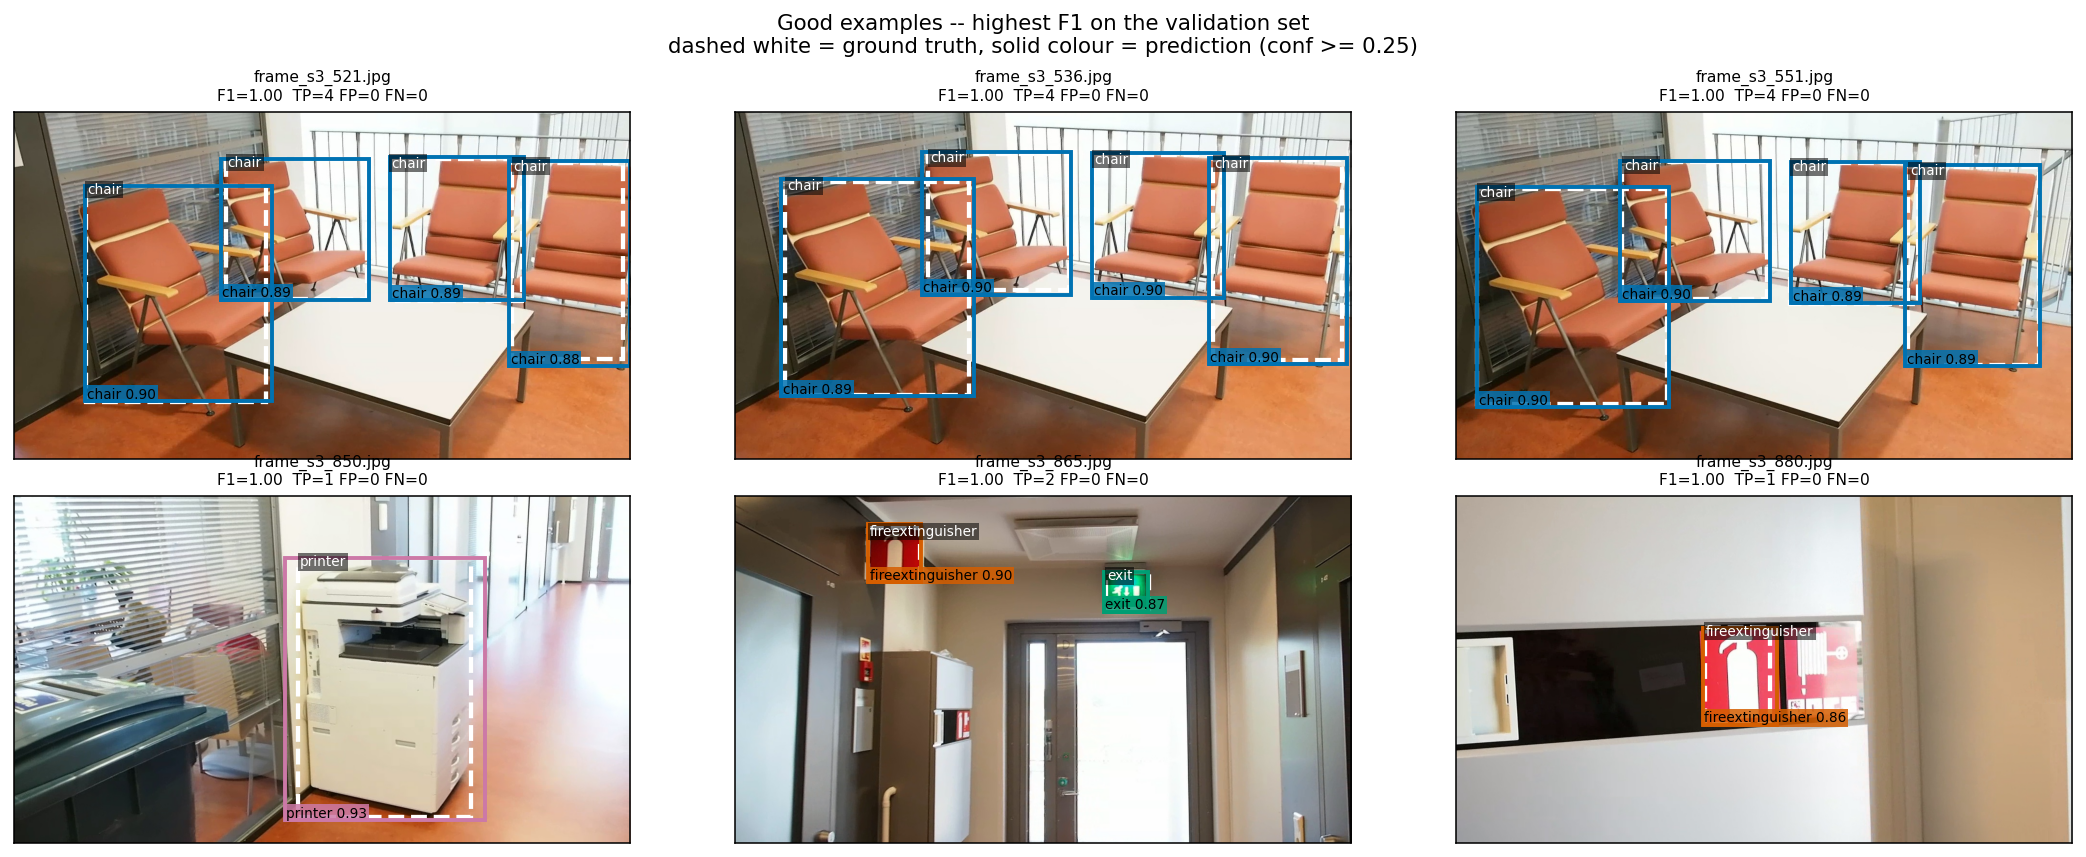

### Bad examples

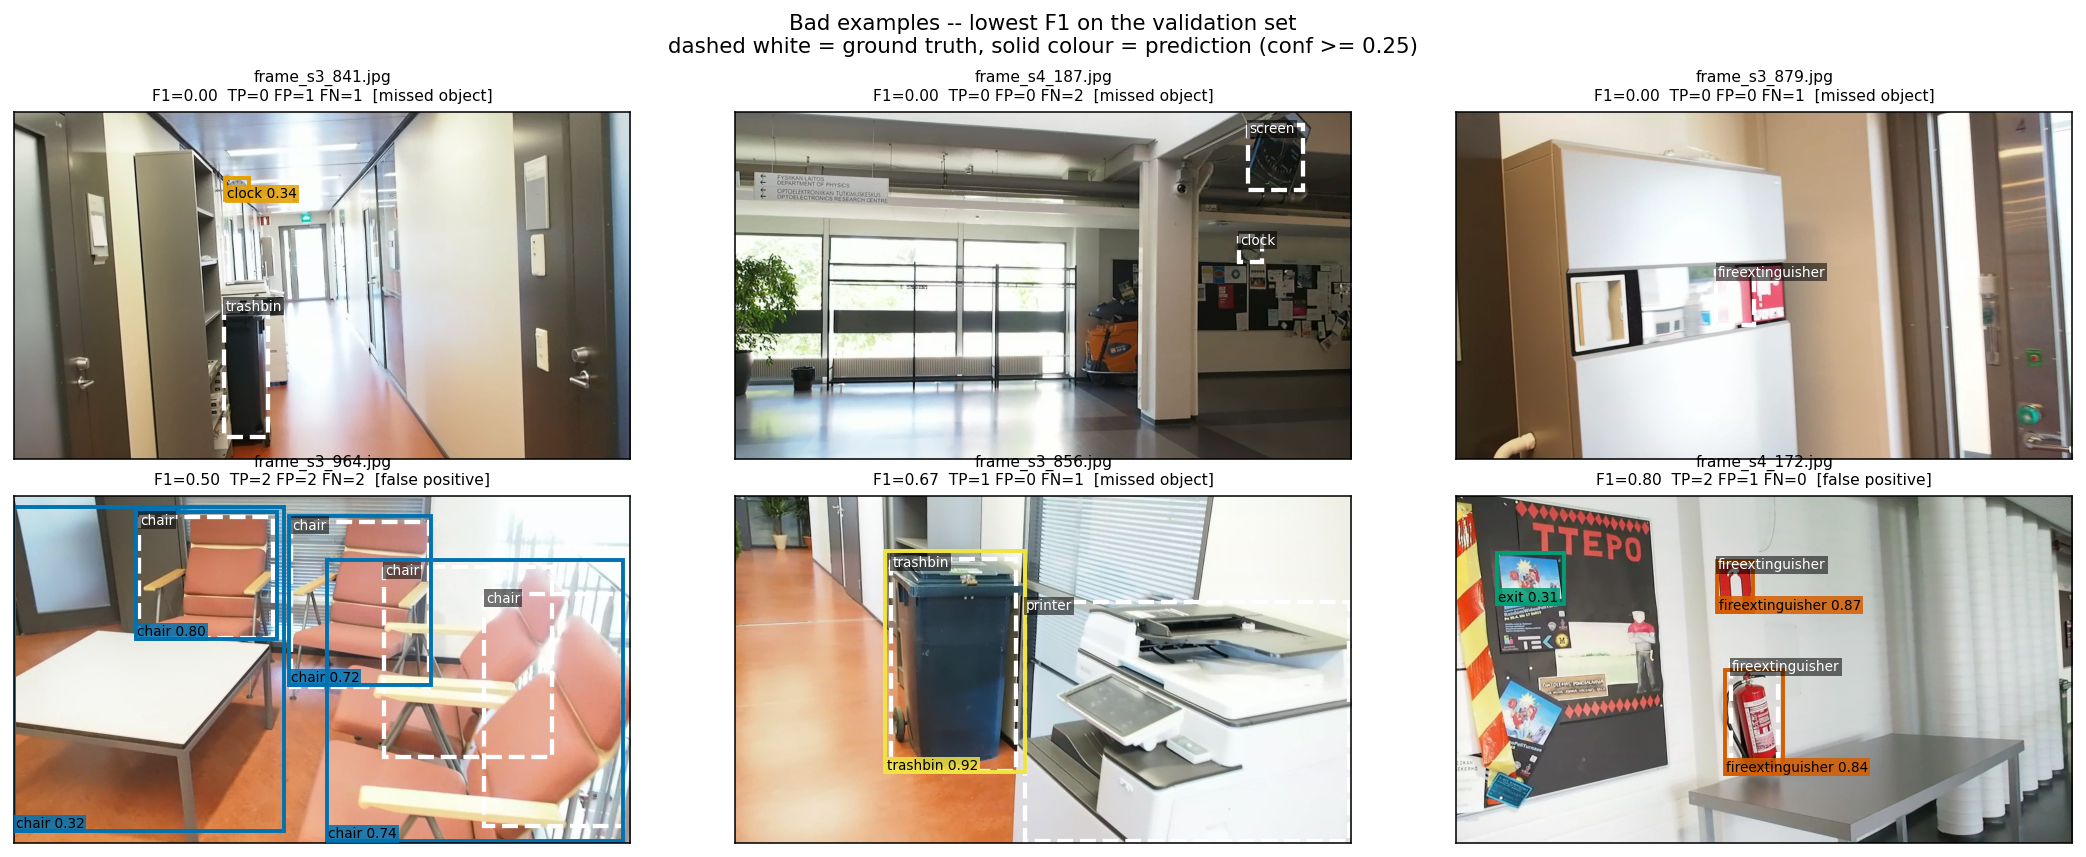

In [9]:
from IPython.display import Image, display, Markdown
display(Markdown('### Good examples'))
display(Image('reports/figures/qualitative_good.png'))
display(Markdown('### Bad examples'))
display(Image('reports/figures/qualitative_bad.png'))

## 6 · Leakage ablation (optional)

Trains the *same* configuration on the naive random split, at a shortened but identical schedule for both, and compares. The gap is the mAP that a random split hands you for free — and that would evaporate on a hidden test set.

Set `RUN_ABLATION = False` to skip (saves roughly 40 minutes).

In [10]:
RUN_ABLATION = True
ABLATION_EPOCHS = 60  # identical for both splits, so the comparison is fair

if RUN_ABLATION:
    import yaml, copy
    base = yaml.safe_load(open('configs/default.yaml'))
    for split_name in ['grouped', 'random']:
        cfg = copy.deepcopy(base)
        cfg['epochs'] = ABLATION_EPOCHS
        cfg['close_mosaic'] = 10
        cfg['name'] = f'ablation_{split_name}'
        path = f'configs/_ablation_{split_name}.yaml'
        yaml.safe_dump(cfg, open(path, 'w'), sort_keys=False)
        !python train.py --config {path} --dataset {split_name} --device 0
        !cp reports/metrics.json reports/metrics_ablation_{split_name}.json

[train] model=yolo11s.pt  data=/content/indoor-object-detection/data/processed/grouped/dataset.yaml
Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/indoor-object-detection/data/processed/grouped/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio

In [11]:
import json
from pathlib import Path

if RUN_ABLATION:
    rows = []
    for split_name in ['grouped', 'random']:
        p = Path(f'reports/metrics_ablation_{split_name}.json')
        if p.exists():
            m = json.loads(p.read_text())['splits']['val']['overall']
            rows.append((split_name, m['mAP@50'], m['mAP@50-95']))
    print(f"{'split':<10}{'mAP@50':>10}{'mAP@50-95':>12}")
    for name, ap50, ap in rows:
        print(f'{name:<10}{ap50:>10.4f}{ap:>12.4f}')
    if len(rows) == 2:
        d50 = rows[1][1] - rows[0][1]
        print(f'\nRandom split reports {d50:+.4f} mAP@50 versus the leak-free split.')
        print('That difference is memorised near-duplicate frames, not detection skill.')

split         mAP@50   mAP@50-95
grouped       0.9493      0.7309
random        0.9829      0.8169

Random split reports +0.0336 mAP@50 versus the leak-free split.
That difference is memorised near-duplicate frames, not detection skill.


## 7 · Inference CLI

The deliverable CLI, run exactly as specified in the brief. It writes `predictions.json` (COCO format), a per-image JSON, and an annotated JPEG for every input image.

In [12]:
!python inference.py --input data/processed/grouped/images/test --output predictions

!ls predictions | head -10
!echo '...' && ls predictions | wc -l

[inference] 229 images | weights=/content/indoor-object-detection/weights/best.pt | conf=0.25
[inference] 400 detections across 229 images -> predictions
frame_s1_100.jpg
frame_s1_100.json
frame_s1_101.jpg
frame_s1_101.json
frame_s1_102.jpg
frame_s1_102.json
frame_s1_103.jpg
frame_s1_103.json
frame_s1_104.jpg
frame_s1_104.json
...
459


400 detections over 229 images


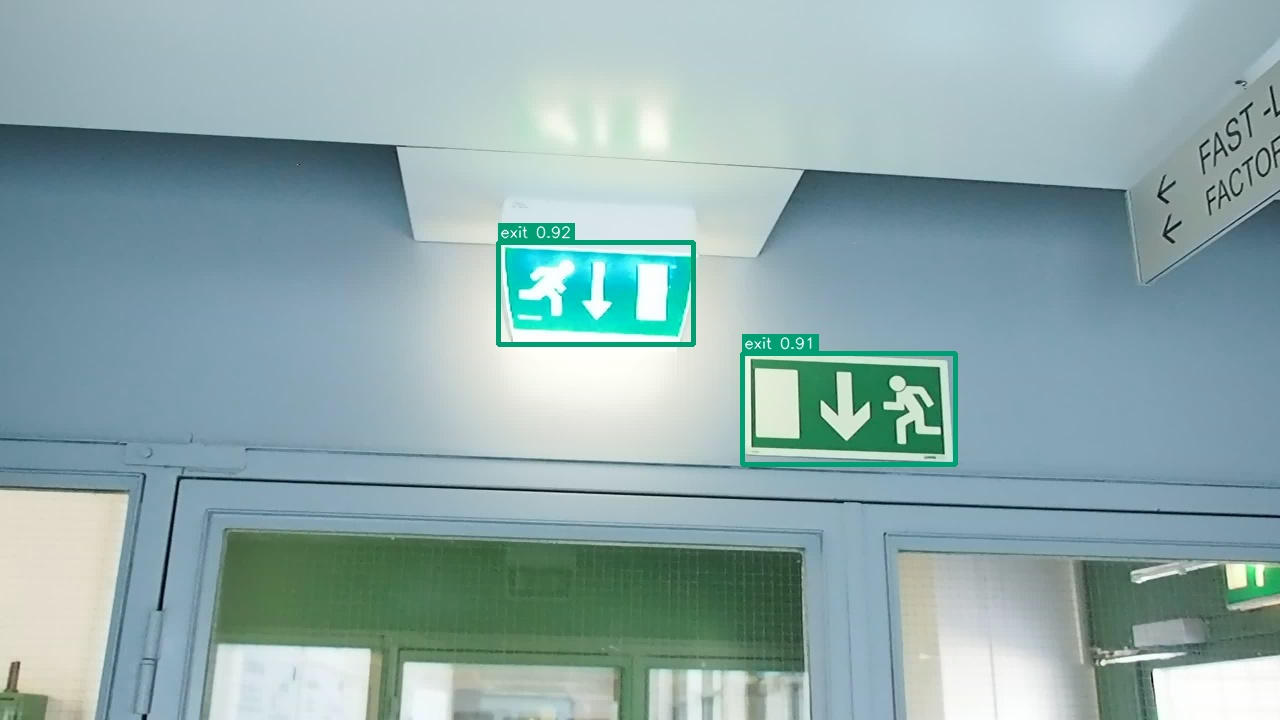

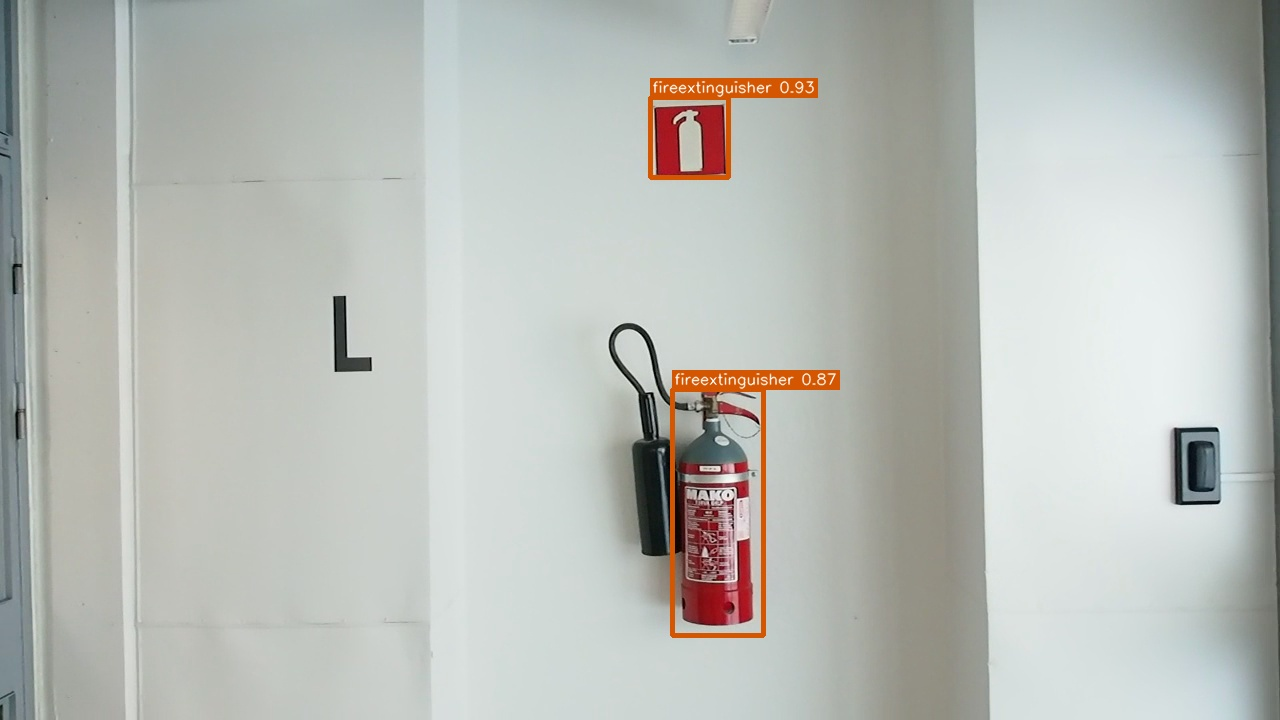

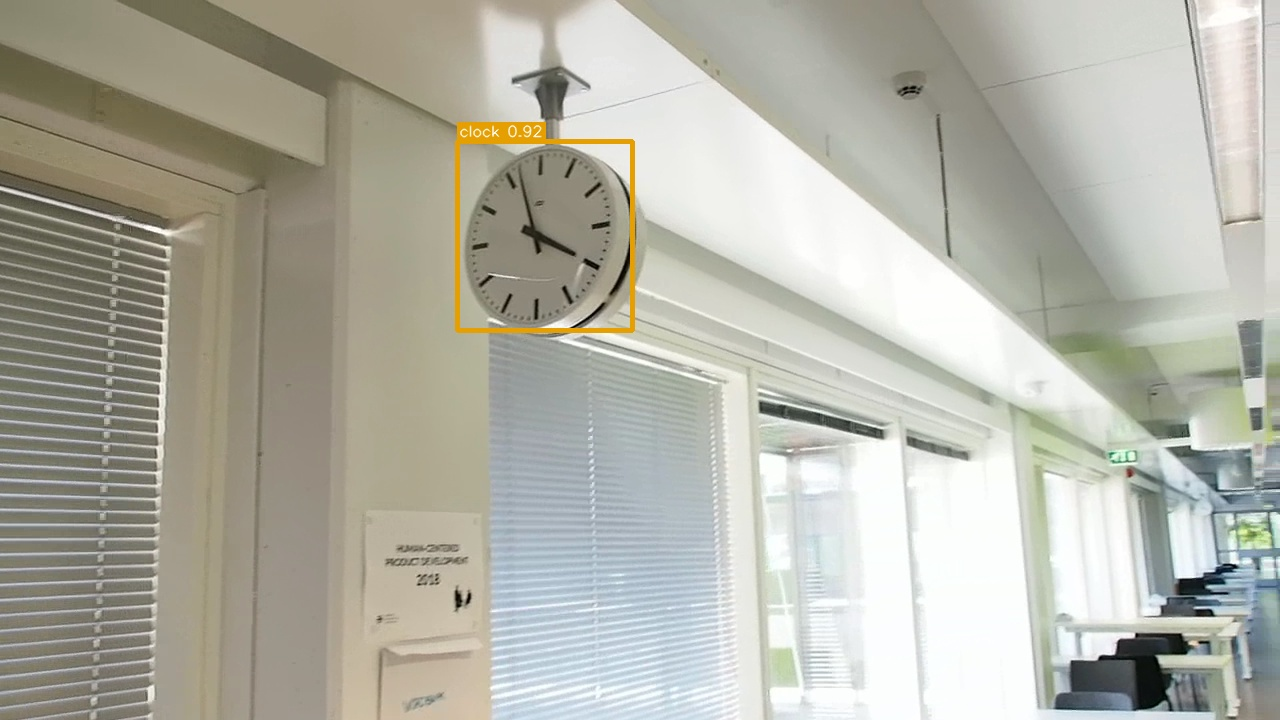

In [13]:
import json
from IPython.display import Image, display

preds = json.load(open('predictions/predictions.json'))
print(f"{len(preds['annotations'])} detections over {len(preds['images'])} images")

# Show a few annotated outputs.
from pathlib import Path
for p in sorted(Path('predictions').glob('*.jpg'))[:3]:
    display(Image(str(p), width=640))

## 8 · Package the submission

Bundles source, trained weights, predictions, metrics and figures into a single zip and downloads it.

In [14]:
!python scripts/package_submission.py

from google.colab import files
files.download('submission.zip')

wrote /content/indoor-object-detection/submission.zip
  496 files, 63.3 MB uncompressed -> 61.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>